**Extraire channels pour l'inference**

In [2]:
import tifffile as tiff

nom_du_fichier = 'Cw_JR_East_2023_05_08_pan_IMG_0009_6_MS_alP1_cor2_RGB_crop'

# Charger l'image TIFF
image = tiff.imread(f"./inference/inputs/{nom_du_fichier}.tif")

# Sélectionner les bons canaux 
channel_selectionnés = 'RGB'
image_selected = image[:, :, [5, 3, 1]]
print(image_selected.shape)

# Sauvegarder l'image avec les canaux sélectionnés
tiff.imwrite(f"{nom_du_fichier}_{channel_selectionnés}.tif", image_selected)

(4269, 7510, 3)


**Visualisation de segmentation**

In [8]:
import rasterio
import numpy as np

# Ouvrir image de segmentation
with rasterio.open("inference/predictions/Cw_JR_East_2023_05_08_pan_IMG_0009_6_MS_alP1_cor2_RGB_crop_seg.tif") as src:
    print(f"Dimensions: {src.shape}")  
    print(f"Nombre de bandes : {src.count}")
    segmentation = src.read(1)

# Statistiques de l’image
print(f"Min: {segmentation.min()}, Max: {segmentation.max()}, Moyenne: {segmentation.mean()}")

Dimensions: (2082, 1369)
Nombre de bandes : 1
Min: 0, Max: 1, Moyenne: 0.007941035513276342


In [9]:
# Normaliser entre 0 et 255
segmentation_normalized = (segmentation - segmentation.min()) / (segmentation.max() - segmentation.min()) * 255
segmentation_normalized = segmentation_normalized.astype(np.uint8)

# Sauvegarder l'image normalisée
with rasterio.open("segmentation_fixed.tif", "w", driver="GTiff",
                   height=segmentation.shape[0], width=segmentation.shape[1],
                   count=1, dtype=segmentation_normalized.dtype) as dst:
    dst.write(segmentation_normalized, 1)

c:\Users\Chris\anaconda3\envs\GLO70302_p\lib\site-packages\rasterio\__init__.py:378: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


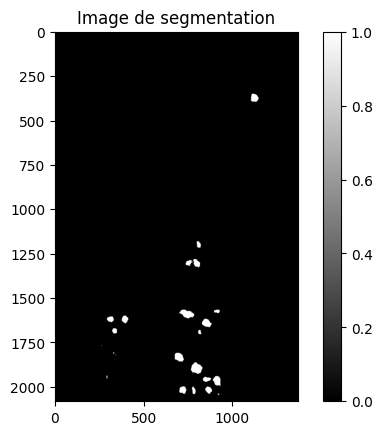

In [10]:
import matplotlib.pyplot as plt

plt.imshow(segmentation, cmap="gray")
plt.colorbar()
plt.title("Image de segmentation")
plt.show()

**Visualisation du fichier tif et des shapefiles**

C:\Users\Chris\AppData\Local\Temp\ipykernel_3972\1553608964.py:30: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
C:\Users\Chris\AppData\Local\Temp\ipykernel_3972\1553608964.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


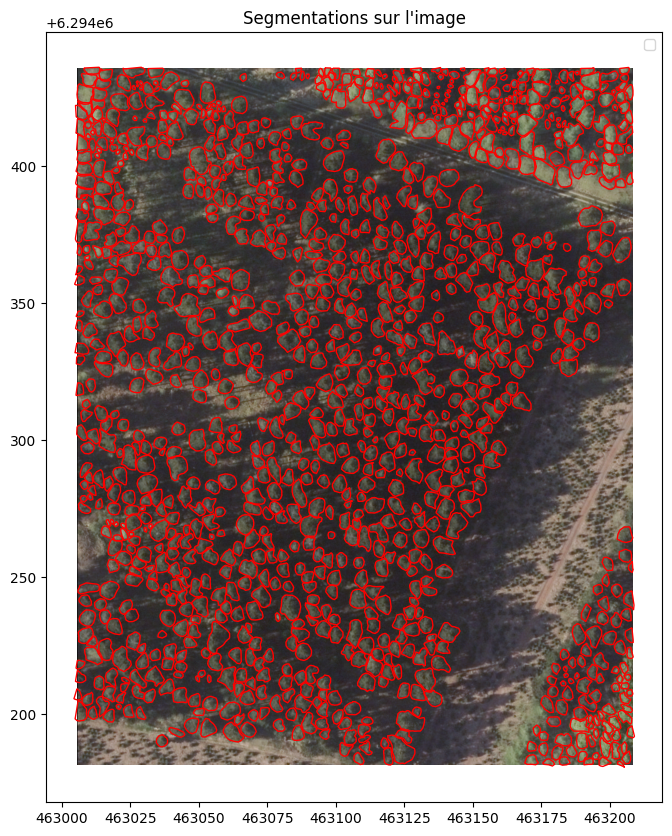

In [ ]:
import rasterio
from rasterio.plot import show
import geopandas as gpd
import matplotlib.pyplot as plt


# Charger l'image
nom_du_fichier = '2018_1km_6294_463_crop'

raster_path = f"./preprocessing/raw_data/{nom_du_fichier}.tif"
raster = rasterio.open(raster_path)

# Charger les shapefiles
gdf_annotation = gpd.read_file(f"./preprocessing/raw_data/example_annotation.shp")
gdf_rectangle = gpd.read_file(f"./preprocessing/raw_data/example_rectangle.shp")

# Afficher
fig, ax = plt.subplots(figsize=(10, 10))
show((raster, [1, 2, 3]), ax=ax) 
gdf_annotation.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=1, label="Annotation")
gdf_rectangle.plot(ax=ax, edgecolor='blue', facecolor='none', linewidth=1, label="Rectangle")
plt.legend()
plt.title("Segmentations sur l'image")
plt.show()